In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [27]:
data = np.loadtxt('/home/runnalja/git/alplakes/simulations/runs/delftwaves_swanv4151_swan_geneva_20260308_20260315_1/bottom.bot', delimiter=None)

In [43]:
data[data == 0] = np.nan
print(data.shape)
data[24,36] = -400

(35, 181)


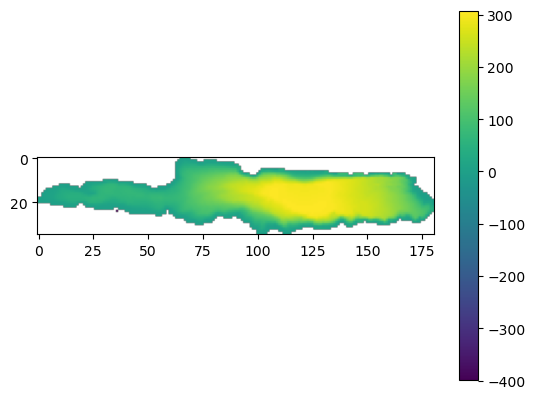

In [44]:
plt.imshow(data)
plt.colorbar()

In [4]:
def validate_2d_swan_grid(filename, mxc, myc):
    """
    Validates a SWAN grid where the file might already be in a 2D matrix format.
    """
    nodes_x = mxc + 1
    nodes_y = myc + 1
    
    # Load the raw data
    raw_data = np.loadtxt(filename)
    print(f"Detected file shape: {raw_data.shape}")

    # Case A: Data is a long 1D vector (or single column)
    if raw_data.ndim == 1 or raw_data.shape[1] == 1:
        data = raw_data.flatten()
        X = data[:nodes_x * nodes_y].reshape((nodes_y, nodes_x))
        Y = data[nodes_x * nodes_y:].reshape((nodes_y, nodes_x))
    
    # Case B: Data is already 2D (Matrix format)
    else:
        # Usually, X blocks and Y blocks are stacked vertically
        # Total rows should be 2 * nodes_y if one row = one grid line
        if raw_data.shape[0] == 2 * nodes_y:
            X = raw_data[:nodes_y, :]
            Y = raw_data[nodes_y:, :]
        else:
            print("Error: Matrix rows don't match 2 * (myc + 1). Check your IDLA.")
            return

    # --- Validation: Shoelace Formula for Area ---
    # Area = 0.5 * |(x1y2 - y1x2) + (x2y3 - y2x3) + (x3y4 - y3x4) + (x4y1 - y4x1)|
    def get_areas(x, y):
        return 0.5 * np.abs(
            x[:-1, :-1] * (y[1:, :-1] - y[:-1, 1:]) +
            x[1:, :-1] * (y[1:, 1:] - y[:-1, :-1]) +
            x[1:, 1:] * (y[:-1, 1:] - y[1:, :-1]) +
            x[:-1, 1:] * (y[:-1, :-1] - y[1:, 1:])
        )

    areas = get_areas(X, Y)
    
    if np.any(areas <= 0):
        print(f"Found {np.sum(areas <= 0)} invalid cells (zero or negative area).")
    else:
        print("Grid geometry looks solid!")

    # Plotting
    plt.figure(figsize=(8, 6))
    for i in range(nodes_y): plt.plot(X[i, :], Y[i, :], 'k-', alpha=0.5)
    for j in range(nodes_x): plt.plot(X[:, j], Y[:, j], 'k-', alpha=0.5)
    plt.gca().set_aspect('equal')
    plt.title("Curvilinear Grid Preview")
    plt.show()

validate_swan_grid('/home/runnalja/git/alplakes/simulations/runs/delftwaves_swanv4151_swan_geneva_20260308_20260315_1/grid_coord.grd', mxc=180, myc=34, idla=1)

ERROR: File contains 70 values, but expected 12670.
Calculation: (mxc+1) * (myc+1) * 2 = (181 * 35) * 2
